# Loan default: EDA and prediction model

The target is `loan_paid_back` (1 = paid back, 0 = default). It is flipped to `default = 1 - loan_paid_back`, and every model predicts the probability of default.

Data: [Loan Prediction Dataset 2025](https://www.kaggle.com/datasets/nabihazahid/loan-prediction-dataset-2025/data) on Kaggle (Apache 2.0). Save it as `loan_dataset_20000.csv` next to this notebook.

In [1]:
import os
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, classification_report,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
%matplotlib inline

RANDOM_STATE = 42
DATA_PATH = "loan_dataset_20000.csv"


## 1. Load data

In [2]:
df = pd.read_csv(DATA_PATH)
print(f"Loaded {df.shape[0]} rows, {df.shape[1]} cols")
print("Missing values:", df.isna().sum().sum())
df.head()


Loaded 20000 rows, 22 cols
Missing values: 0


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [3]:
TARGET = "loan_paid_back"
df["default"] = 1 - df[TARGET]

num_cols = [
    "age", "annual_income", "monthly_income", "debt_to_income_ratio",
    "credit_score", "loan_amount", "interest_rate", "loan_term",
    "installment", "num_of_open_accounts", "total_credit_limit",
    "current_balance", "delinquency_history", "public_records",
    "num_of_delinquencies",
]
cat_cols = [
    "gender", "marital_status", "education_level", "employment_status",
    "loan_purpose", "grade_subgrade",
]


## 2. EDA
### 2.1 Target balance

default
0    0.7999
1    0.2001
Name: pct, dtype: float64


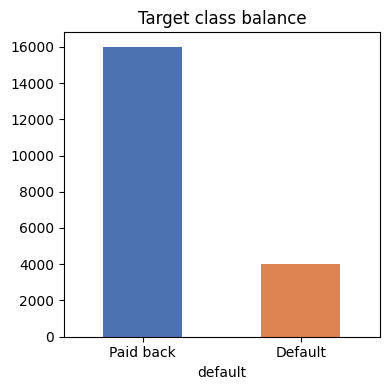

In [4]:
print(df["default"].value_counts(normalize=True).rename("pct"))

plt.figure(figsize=(4, 4))
df["default"].value_counts().sort_index().plot(kind="bar", color=["#4C72B0", "#DD8452"])
plt.xticks([0, 1], ["Paid back", "Default"], rotation=0)
plt.title("Target class balance")
plt.tight_layout()
plt.show()


### 2.2 Numeric feature summary

In [5]:
df[num_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
age,20000.0,48.027000,15.829352,21.00,35.0000,48.000,62.0000,75.000
annual_income,20000.0,43549.637766,28668.579671,6000.00,24260.7525,36585.260,54677.9175,400000.000
monthly_income,20000.0,3629.136466,2389.048326,500.00,2021.7300,3048.770,4556.4950,33333.330
debt_to_income_ratio,20000.0,0.177019,0.105059,0.01,0.0960,0.160,0.2410,0.667
credit_score,20000.0,679.256950,69.638580,373.00,632.0000,680.000,727.0000,850.000
loan_amount,20000.0,15129.300909,8605.405513,500.00,8852.6950,14946.170,20998.8675,49039.690
interest_rate,20000.0,12.400626,2.442729,3.14,10.7400,12.400,14.0025,22.510
loan_term,20000.0,43.222800,11.008380,36.00,36.0000,36.000,60.0000,60.000
installment,20000.0,455.625794,274.622125,9.43,253.9100,435.595,633.5950,1685.400
num_of_open_accounts,20000.0,5.011800,2.244529,0.00,3.0000,5.000,6.0000,15.000


### 2.3 Numeric distributions by default status

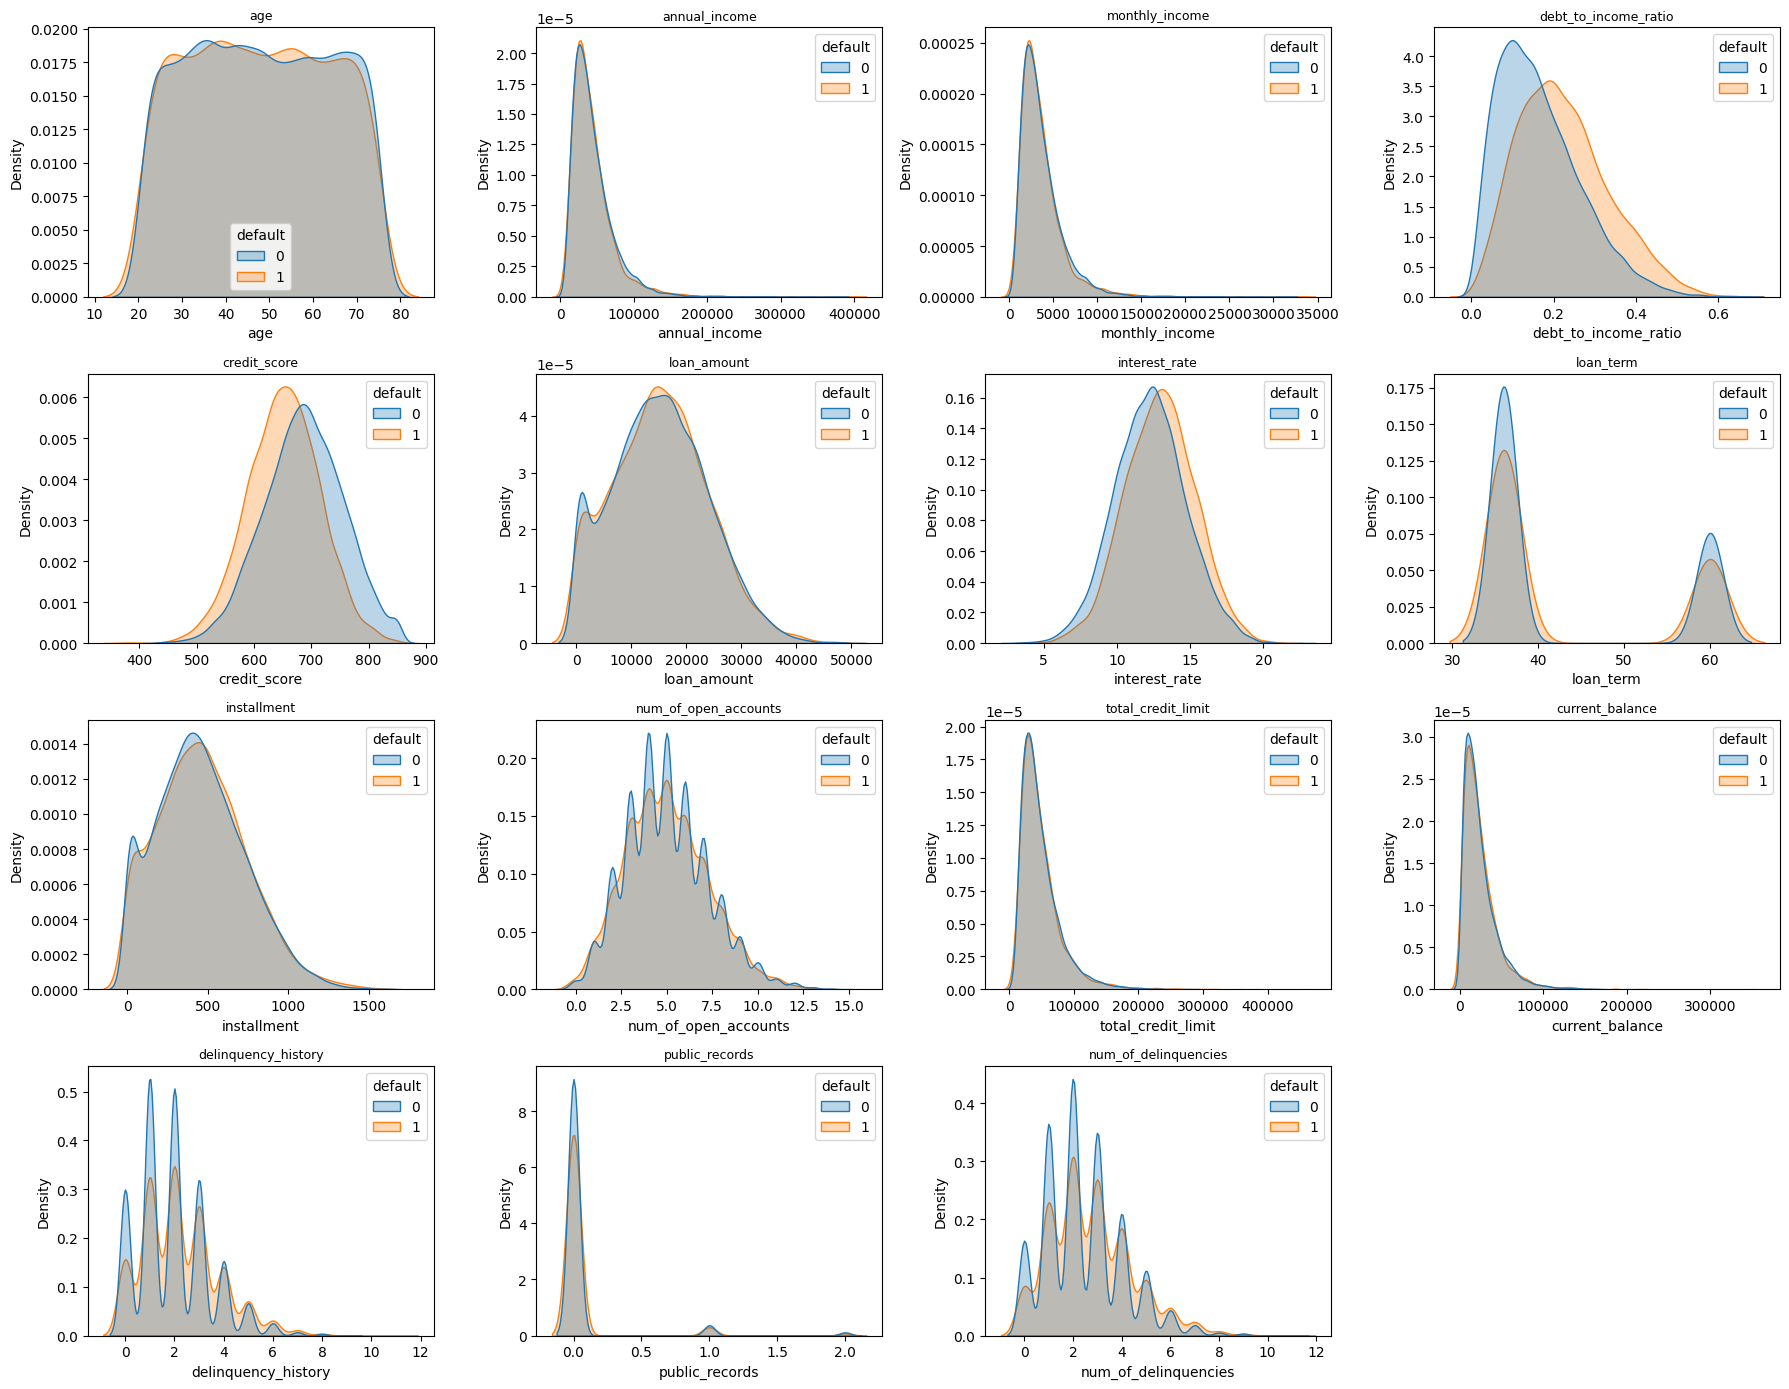

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flat, num_cols):
    sns.kdeplot(data=df, x=col, hue="default", ax=ax, common_norm=False, fill=True, alpha=0.3)
    ax.set_title(col, fontsize=9)
for ax in axes.flat[len(num_cols):]:
    ax.axis("off")
plt.tight_layout()
plt.show()


### 2.4 Correlation matrix

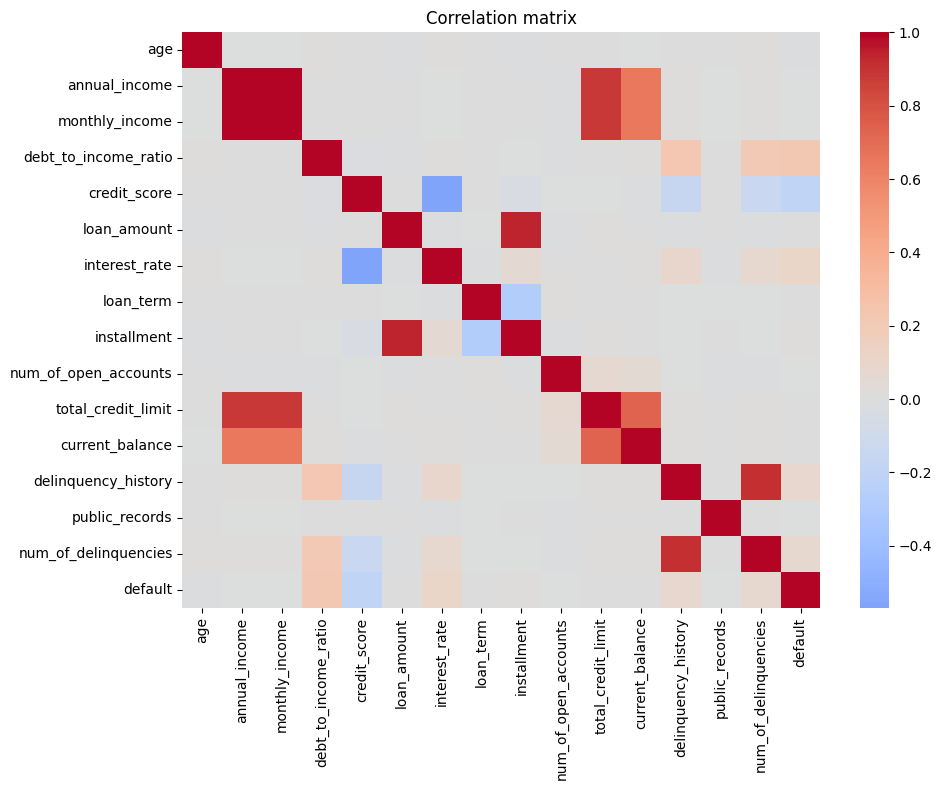

default                 1.000000
debt_to_income_ratio    0.223831
interest_rate           0.110935
delinquency_history     0.084940
num_of_delinquencies    0.070896
installment             0.010068
current_balance         0.004749
total_credit_limit      0.002985
loan_term               0.002615
loan_amount             0.002490
num_of_open_accounts   -0.002964
annual_income          -0.003057
monthly_income         -0.003057
public_records         -0.003210
age                    -0.007999
credit_score           -0.199841
Name: default, dtype: float64

In [7]:
plt.figure(figsize=(10, 8))
corr = df[num_cols + ["default"]].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

corr["default"].sort_values(ascending=False)


### 2.5 Default rate by categorical feature

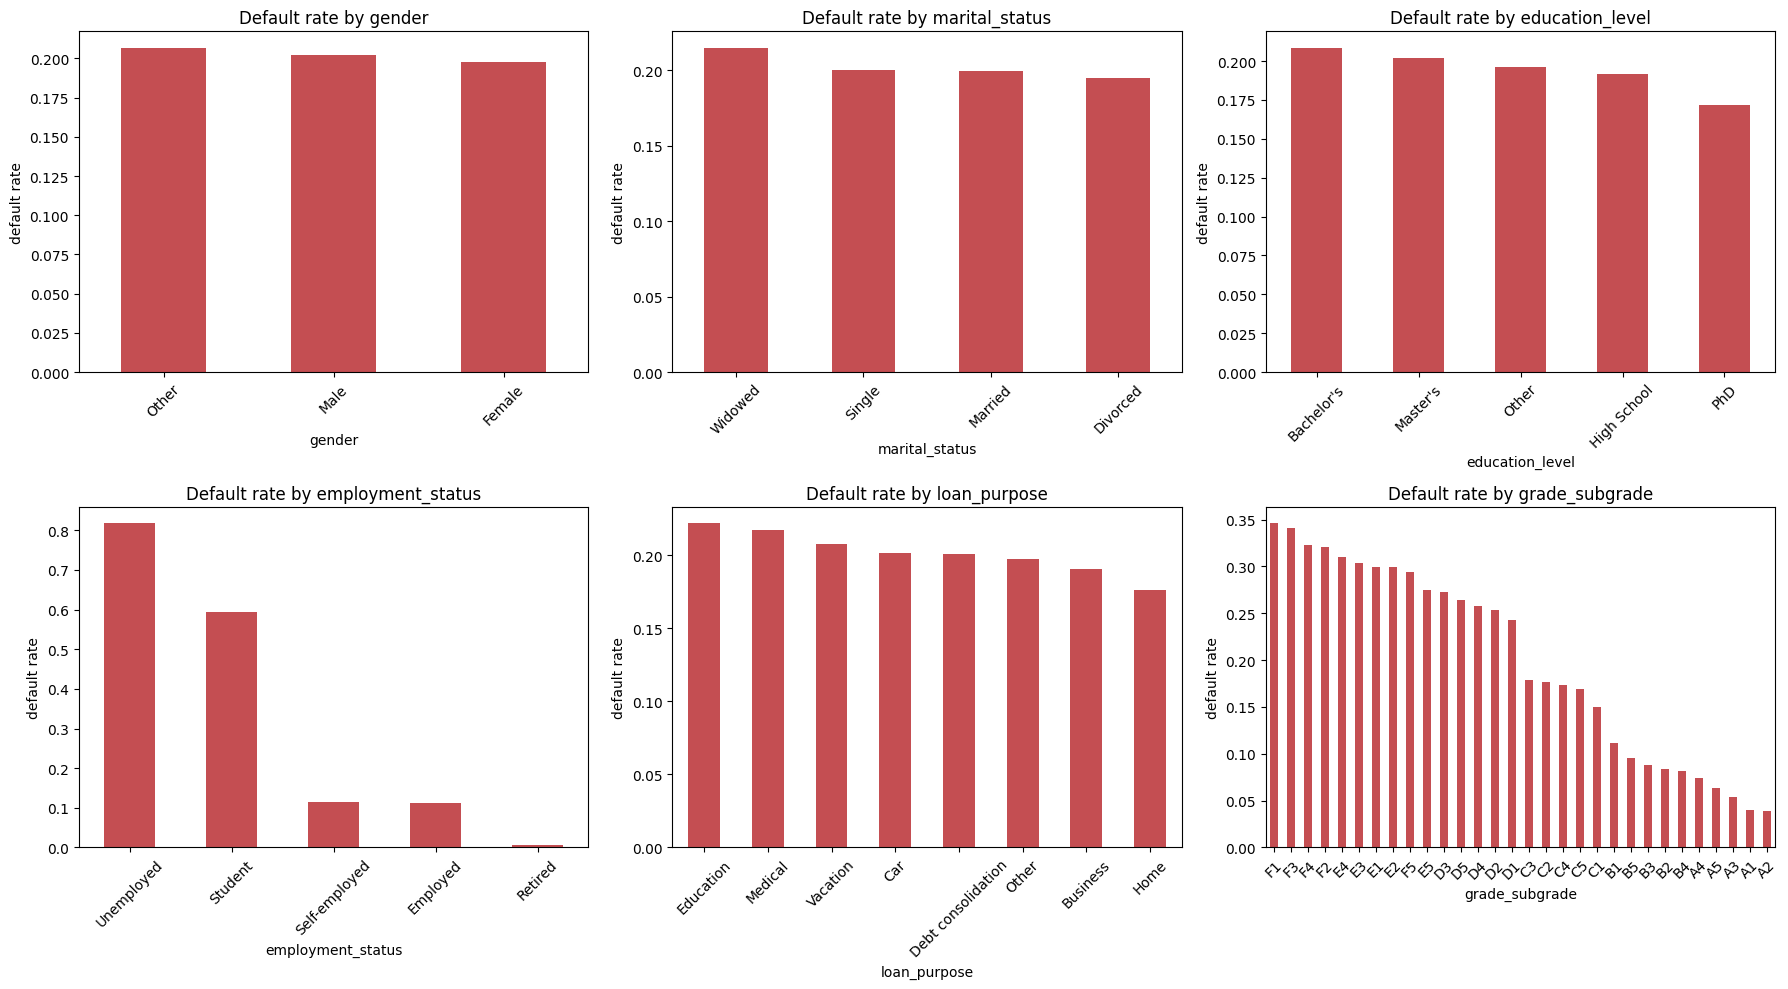

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)["default"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_title(f"Default rate by {col}")
    ax.set_ylabel("default rate")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


In [9]:
for col in cat_cols:
    print(f"\n{col}:")
    print(df.groupby(col)["default"].agg(["mean", "count"]).sort_values("mean", ascending=False))



gender:
            mean  count
gender                 
Other   0.206977    430
Male    0.202496   9536
Female  0.197528  10034

marital_status:
                    mean  count
marital_status                 
Widowed         0.215168    567
Single          0.200421   9031
Married         0.199688   8974
Divorced        0.194678   1428

education_level:
                     mean  count
education_level                 
Bachelor's       0.208701   8045
Master's         0.202202   3724
Other            0.196286   1508
High School      0.191924   5919
PhD              0.171642    804

employment_status:
                       mean  count
employment_status                 
Unemployed         0.818268   2113
Student            0.592830    781
Self-employed      0.114266   2923
Employed           0.113016  13007
Retired            0.005102   1176

loan_purpose:
                        mean  count
loan_purpose                       
Education           0.222090   1675
Medical             0.217

## 3. Train / test split and preprocessing

In [10]:
X = df[num_cols + cat_cols]
y = df["default"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols),
    ]
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()


Train: (16000, 21), Test: (4000, 21)


## 4. Models: Logistic Regression, Random Forest, XGBoost

In [11]:
models = {
    "logistic_regression": Pipeline([
        ("prep", preprocess),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    "random_forest": Pipeline([
        ("prep", preprocess),
        ("clf", RandomForestClassifier(
            n_estimators=400, max_depth=8, min_samples_leaf=20,
            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
    "xgboost": Pipeline([
        ("prep", preprocess),
        ("clf", XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
        )),
    ]),
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)

    auc = roc_auc_score(y_test, proba)
    ap = average_precision_score(y_test, proba)
    report = classification_report(y_test, pred, output_dict=True)
    cm = confusion_matrix(y_test, pred).tolist()

    results[name] = {
        "roc_auc": auc,
        "avg_precision": ap,
        "classification_report": report,
        "confusion_matrix": cm,
    }
    print(f"\n=== {name} ===")
    print(f"ROC-AUC: {auc:.4f}  |  PR-AUC: {ap:.4f}")
    print(classification_report(y_test, pred))
    print("Confusion matrix (rows=true, cols=pred):")
    print(np.array(cm))



=== logistic_regression ===
ROC-AUC: 0.8861  |  PR-AUC: 0.7717
              precision    recall  f1-score   support

           0       0.93      0.83      0.87      3200
           1       0.51      0.73      0.60       800

    accuracy                           0.81      4000
   macro avg       0.72      0.78      0.74      4000
weighted avg       0.84      0.81      0.82      4000

Confusion matrix (rows=true, cols=pred):
[[2643  557]
 [ 214  586]]



=== random_forest ===
ROC-AUC: 0.8816  |  PR-AUC: 0.7694
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      3200
           1       0.55      0.69      0.62       800

    accuracy                           0.83      4000
   macro avg       0.74      0.78      0.75      4000
weighted avg       0.85      0.83      0.83      4000

Confusion matrix (rows=true, cols=pred):
[[2754  446]
 [ 245  555]]



=== xgboost ===
ROC-AUC: 0.8918  |  PR-AUC: 0.7865
              precision    recall  f1-score   support

           0       0.92      0.87      0.90      3200
           1       0.58      0.70      0.63       800

    accuracy                           0.84      4000
   macro avg       0.75      0.79      0.77      4000
weighted avg       0.85      0.84      0.84      4000

Confusion matrix (rows=true, cols=pred):
[[2793  407]
 [ 240  560]]


### 4.1 ROC and Precision-Recall curves

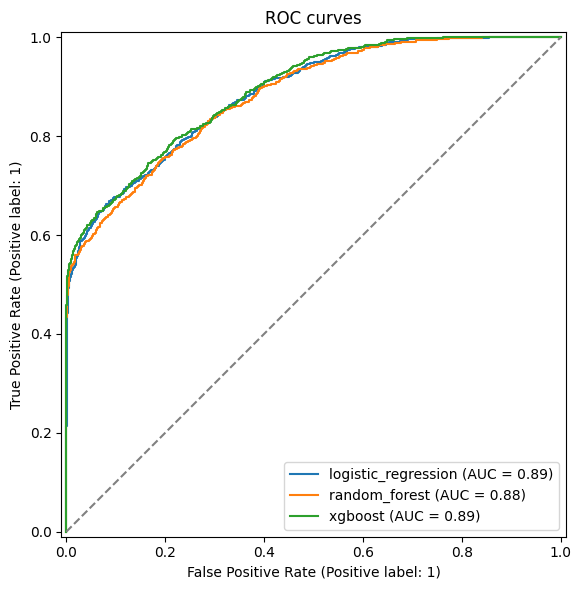

In [12]:
plt.figure(figsize=(6, 6))
for name, pipe in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=plt.gca())
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("ROC curves")
plt.tight_layout()
plt.show()


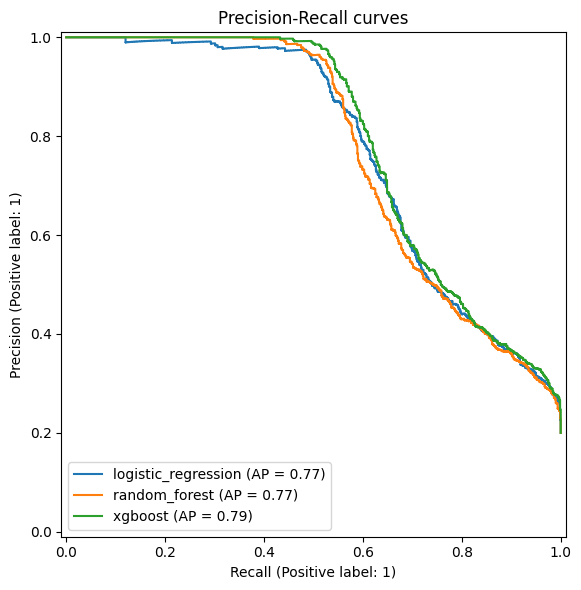

In [13]:
plt.figure(figsize=(6, 6))
for name, pipe in models.items():
    PrecisionRecallDisplay.from_estimator(pipe, X_test, y_test, name=name, ax=plt.gca())
plt.title("Precision-Recall curves")
plt.tight_layout()
plt.show()


In [14]:
best_name = max(results, key=lambda k: results[k]["roc_auc"])
print(f"Best model by ROC-AUC: {best_name} ({results[best_name]['roc_auc']:.4f})")


Best model by ROC-AUC: xgboost (0.8918)


## 5. Feature importance (best model)

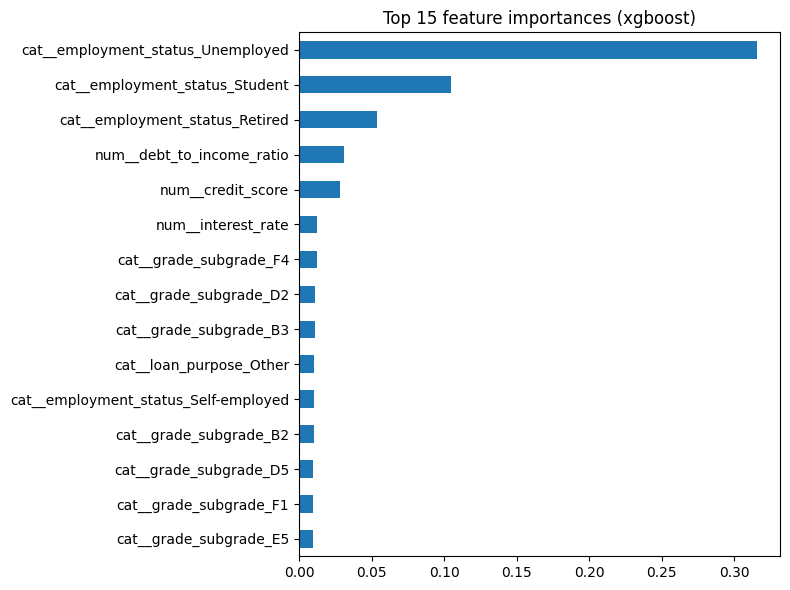

In [15]:
best_pipe = models[best_name]
if hasattr(best_pipe.named_steps["clf"], "feature_importances_"):
    feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
    importances = best_pipe.named_steps["clf"].feature_importances_
    fi = pd.Series(importances, index=feat_names).sort_values(ascending=False)

    plt.figure(figsize=(8, 6))
    fi.head(15).sort_values().plot(kind="barh")
    plt.title(f"Top 15 feature importances ({best_name})")
    plt.tight_layout()
    plt.show()

    fi.head(15)


## 6. Monotonic constraints (financial domain rules)

The models above (logistic regression, random forest, XGBoost) have no monotonic constraints. A tree or boosting model can fit a non-monotonic relationship between any feature and default probability, even where finance says the relationship must run one way. For example, it could learn that default risk dips at some high debt-to-income value, which makes no financial sense and is most likely noise.

XGBoost's `monotone_constraints` forces each feature's marginal effect on the predicted probability to be non-decreasing (`+1`), non-increasing (`-1`) or unconstrained (`0`). XGBoost is refit here with constraints based on standard credit-risk logic, then compared with the unconstrained version.

In [16]:
# +1: never lowers predicted risk, -1: never raises it, 0: unconstrained
monotonic_direction = {
    "age": 0,
    "annual_income": -1,
    "monthly_income": -1,
    "debt_to_income_ratio": 1,
    "credit_score": -1,
    "loan_amount": 1,
    "interest_rate": 1,
    "loan_term": 0,
    "installment": 1,
    "num_of_open_accounts": 0,
    "total_credit_limit": 0,
    "current_balance": 0,
    "delinquency_history": 1,
    "public_records": 1,
    "num_of_delinquencies": 1,
}
assert set(monotonic_direction) == set(num_cols)

preprocess.fit(X_train)
n_cat_expanded = len(preprocess.named_transformers_["cat"].get_feature_names_out())
monotone_constraints = tuple(monotonic_direction[c] for c in num_cols) + (0,) * n_cat_expanded

print("Monotone constraints vector (num_cols then one-hot cat columns):")
print(monotone_constraints)


Monotone constraints vector (num_cols then one-hot cat columns):
(0, -1, -1, 1, -1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)


In [17]:
xgb_constrained = Pipeline([
    ("prep", preprocess),
    ("clf", XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        monotone_constraints=monotone_constraints,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
    )),
])
xgb_constrained.fit(X_train, y_train)

proba_c = xgb_constrained.predict_proba(X_test)[:, 1]
pred_c = (proba_c >= 0.5).astype(int)

auc_c = roc_auc_score(y_test, proba_c)
ap_c = average_precision_score(y_test, proba_c)

results["xgboost_monotonic"] = {
    "roc_auc": auc_c,
    "avg_precision": ap_c,
    "classification_report": classification_report(y_test, pred_c, output_dict=True),
    "confusion_matrix": confusion_matrix(y_test, pred_c).tolist(),
}
models["xgboost_monotonic"] = xgb_constrained

print("=== xgboost_monotonic ===")
print(f"ROC-AUC: {auc_c:.4f}  |  PR-AUC: {ap_c:.4f}   (unconstrained xgboost: "
      f"ROC-AUC {results['xgboost']['roc_auc']:.4f} | PR-AUC {results['xgboost']['avg_precision']:.4f})")
print(classification_report(y_test, pred_c))
print("Confusion matrix (rows=true, cols=pred):")
print(np.array(results["xgboost_monotonic"]["confusion_matrix"]))


=== xgboost_monotonic ===
ROC-AUC: 0.8932  |  PR-AUC: 0.7891   (unconstrained xgboost: ROC-AUC 0.8918 | PR-AUC 0.7865)
              precision    recall  f1-score   support

           0       0.93      0.86      0.89      3200
           1       0.57      0.72      0.63       800

    accuracy                           0.83      4000
   macro avg       0.75      0.79      0.76      4000
weighted avg       0.85      0.83      0.84      4000

Confusion matrix (rows=true, cols=pred):
[[2759  441]
 [ 223  577]]


In [18]:
import copy

def check_monotonic(pipe, feature, direction, n_points=25):
    if direction == 0:
        return None
    base = X_train.median(numeric_only=True).to_dict()
    for c in cat_cols:
        base[c] = X_train[c].mode()[0]
    grid = np.linspace(X_train[feature].min(), X_train[feature].max(), n_points)
    rows = []
    for v in grid:
        row = copy.deepcopy(base)
        row[feature] = v
        rows.append(row)
    grid_df = pd.DataFrame(rows)[num_cols + cat_cols]
    proba = pipe.predict_proba(grid_df)[:, 1]
    diffs = np.diff(proba)
    if direction == 1:
        ok = np.all(diffs >= -1e-9)
    else:
        ok = np.all(diffs <= 1e-9)
    return ok

print(f"{'feature':<25}{'direction':>10}{'holds?':>10}")
for feat, d in monotonic_direction.items():
    if d == 0:
        continue
    ok = check_monotonic(xgb_constrained, feat, d)
    print(f"{feat:<25}{d:>10}{str(ok):>10}")


feature                   direction    holds?
annual_income                    -1      True
monthly_income                   -1      True
debt_to_income_ratio              1      True
credit_score                     -1      True
loan_amount                       1      True
interest_rate                     1      True
installment                       1      True
delinquency_history               1      True
public_records                    1      True
num_of_delinquencies              1      True


## 7. Cross-validation (robustness check)

Every metric so far comes from a single 80/20 split. That is one sample of how the model performs on unseen data, and it says nothing about how much the number would move on a different split. 5-fold stratified cross-validation on the training set gives a mean and spread instead of a point estimate. It uses the same monotonic XGBoost pipeline, unfitted and refit fold by fold. The test set stays untouched.

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.base import clone

cv_pipe = clone(xgb_constrained)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = cross_validate(
    cv_pipe, X_train, y_train, cv=cv,
    scoring=["roc_auc", "average_precision"], n_jobs=-1,
)

print("5-fold CV on training set (monotonic XGBoost, same hyperparameters):")
print(f"  ROC-AUC : {cv_results['test_roc_auc'].mean():.4f} +/- {cv_results['test_roc_auc'].std():.4f}  "
      f"(folds: {np.round(cv_results['test_roc_auc'], 4)})")
print(f"  PR-AUC  : {cv_results['test_average_precision'].mean():.4f} +/- {cv_results['test_average_precision'].std():.4f}  "
      f"(folds: {np.round(cv_results['test_average_precision'], 4)})")
print(f"\nFor reference, the single held-out test set gave ROC-AUC={results['xgboost_monotonic']['roc_auc']:.4f}, "
      f"PR-AUC={results['xgboost_monotonic']['avg_precision']:.4f} — within the CV spread above confirms "
      f"the test-set result isn't a lucky/unlucky split.")


5-fold CV on training set (monotonic XGBoost, same hyperparameters):
  ROC-AUC : 0.8890 +/- 0.0046  (folds: [0.8882 0.8909 0.896  0.8819 0.8879])
  PR-AUC  : 0.7818 +/- 0.0091  (folds: [0.7865 0.7799 0.7935 0.766  0.7831])

For reference, the single held-out test set gave ROC-AUC=0.8932, PR-AUC=0.7891 — within the CV spread above confirms the test-set result isn't a lucky/unlucky split.


## 8. Hyperparameter tuning

The XGBoost hyperparameters used so far (`n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8`) were picked by hand. A randomized search checks whether they are close to optimal. `monotone_constraints` stays fixed, since it is a domain requirement and not a tuning knob. The search is scored on ROC-AUC with 3-fold CV on the training set. The test set is used once, at the end, to compare the tuned model with the current one.

In [20]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = {
    "clf__n_estimators": randint(150, 600),
    "clf__max_depth": randint(3, 7),
    "clf__learning_rate": uniform(0.01, 0.14),
    "clf__subsample": uniform(0.6, 0.4),
    "clf__colsample_bytree": uniform(0.6, 0.4),
    "clf__min_child_weight": randint(1, 10),
    "clf__reg_lambda": uniform(0.5, 4.5),
}

search = RandomizedSearchCV(
    clone(xgb_constrained), param_distributions=param_dist, n_iter=25,
    scoring="roc_auc", cv=3, random_state=RANDOM_STATE, n_jobs=-1, refit=True,
)
search.fit(X_train, y_train)

print("Best CV ROC-AUC during search:", round(search.best_score_, 4))
print("Best params found:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")

tuned_proba_test = search.best_estimator_.predict_proba(X_test)[:, 1]
tuned_auc = roc_auc_score(y_test, tuned_proba_test)
tuned_ap = average_precision_score(y_test, tuned_proba_test)
print(f"\nTuned model on held-out test set: ROC-AUC={tuned_auc:.4f}, PR-AUC={tuned_ap:.4f}")
print(f"Current (hand-picked) model on the same test set: "
      f"ROC-AUC={results['xgboost_monotonic']['roc_auc']:.4f}, "
      f"PR-AUC={results['xgboost_monotonic']['avg_precision']:.4f}")


Best CV ROC-AUC during search: 0.8926
Best params found:
  clf__colsample_bytree: 0.7323592099410596
  clf__learning_rate: 0.01889816904004331
  clf__max_depth: 5
  clf__min_child_weight: 8
  clf__n_estimators: 442
  clf__reg_lambda: 3.783227802521288
  clf__subsample: 0.8550229885420852

Tuned model on held-out test set: ROC-AUC=0.8963, PR-AUC=0.7932
Current (hand-picked) model on the same test set: ROC-AUC=0.8932, PR-AUC=0.7891


Decision: keep the hand-picked hyperparameters.

The search found a modestly better configuration (ROC-AUC 0.8963 vs. 0.8932, PR-AUC 0.7932 vs. 0.7891, about +0.3 points). That gap is smaller than the +/-0.46-point fold-to-fold spread from the cross-validation, so it is within noise. Adopting it would mean rerunning calibration, EL/CECL, pricing and the fair-lending audit, since each depends on the model before it, for a change that cannot be told apart from sampling variation. The simpler hyperparameters stay as the production model for the rest of the notebook. The tuned values are recorded above for a future pass with a bigger search budget or more data, where a small gain would be easier to confirm.

## 9. Probability calibration

Everything downstream in this notebook (portfolio EL/CECL, the RAROC pricing optimizer, the fair-lending approval decisions) uses the predicted probability directly as PD. That only works if `predict_proba` is calibrated: among all loans predicted at PD = 30%, about 30% should default. XGBoost trained with `scale_pos_weight` (used here for the 80/20 imbalance) gives this up, because reweighting the loss shifts predicted probabilities away from true frequencies.

The raw `xgboost_monotonic` model is checked first with a calibration curve (predicted PD against observed default rate, binned by predicted PD). Once the miscalibration is confirmed, `sklearn.calibration.CalibratedClassifierCV` (isotonic regression, 5-fold, refit on top of the same pipeline) corrects it. Isotonic regression is a non-decreasing map, so it cannot change how applicants are ranked. ROC-AUC is preserved, and only the translation from raw score to probability changes.

Sections 10 to 13 use the calibrated PD, not the raw model output.

In [21]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.base import clone

raw_model = models["xgboost_monotonic"]
raw_proba_test = raw_model.predict_proba(X_test)[:, 1]

print(f"Raw model Brier score: {brier_score_loss(y_test, raw_proba_test):.4f}")
frac_pos_raw, mean_pred_raw = calibration_curve(y_test, raw_proba_test, n_bins=10, strategy="quantile")
print("bin: mean predicted PD -> observed default rate (raw model)")
for mp, fp in zip(mean_pred_raw, frac_pos_raw):
    print(f"  {mp:.3f}  ->  {fp:.3f}   (gap={fp - mp:+.3f})")


Raw model Brier score: 0.1131
bin: mean predicted PD -> observed default rate (raw model)
  0.004  ->  0.000   (gap=-0.004)
  0.021  ->  0.000   (gap=-0.021)
  0.070  ->  0.018   (gap=-0.053)
  0.151  ->  0.068   (gap=-0.084)
  0.235  ->  0.092   (gap=-0.143)
  0.319  ->  0.150   (gap=-0.169)
  0.406  ->  0.152   (gap=-0.254)
  0.507  ->  0.190   (gap=-0.317)
  0.683  ->  0.347   (gap=-0.335)
  0.986  ->  0.983   (gap=-0.004)


In [22]:
calibrated_xgb = CalibratedClassifierCV(clone(xgb_constrained), method="isotonic", cv=5)
calibrated_xgb.fit(X_train, y_train)

cal_proba_test = calibrated_xgb.predict_proba(X_test)[:, 1]
cal_pred_test = (cal_proba_test >= 0.5).astype(int)

auc_cal = roc_auc_score(y_test, cal_proba_test)
ap_cal = average_precision_score(y_test, cal_proba_test)
brier_cal = brier_score_loss(y_test, cal_proba_test)

results["xgboost_monotonic_calibrated"] = {
    "roc_auc": auc_cal,
    "avg_precision": ap_cal,
    "classification_report": classification_report(y_test, cal_pred_test, output_dict=True),
    "confusion_matrix": confusion_matrix(y_test, cal_pred_test).tolist(),
}
models["xgboost_monotonic_calibrated"] = calibrated_xgb

print(f"Calibrated model Brier score: {brier_cal:.4f}  (raw was {brier_score_loss(y_test, raw_proba_test):.4f})")
print(f"Calibrated ROC-AUC: {auc_cal:.4f}  |  PR-AUC: {ap_cal:.4f}  "
      f"(raw: ROC-AUC {results['xgboost_monotonic']['roc_auc']:.4f} | "
      f"PR-AUC {results['xgboost_monotonic']['avg_precision']:.4f})")

frac_pos_cal, mean_pred_cal = calibration_curve(y_test, cal_proba_test, n_bins=10, strategy="quantile")
print("\nbin: mean predicted PD -> observed default rate (calibrated model)")
for mp, fp in zip(mean_pred_cal, frac_pos_cal):
    print(f"  {mp:.3f}  ->  {fp:.3f}   (gap={fp - mp:+.3f})")


Calibrated model Brier score: 0.0786  (raw was 0.1131)
Calibrated ROC-AUC: 0.8933  |  PR-AUC: 0.7885  (raw: ROC-AUC 0.8932 | PR-AUC 0.7891)

bin: mean predicted PD -> observed default rate (calibrated model)
  0.000  ->  0.000   (gap=+0.000)
  0.005  ->  0.003   (gap=-0.002)
  0.027  ->  0.017   (gap=-0.010)
  0.063  ->  0.070   (gap=+0.008)
  0.100  ->  0.100   (gap=-0.001)
  0.132  ->  0.118   (gap=-0.014)
  0.158  ->  0.163   (gap=+0.005)
  0.199  ->  0.205   (gap=+0.006)
  0.341  ->  0.340   (gap=-0.001)
  0.986  ->  0.985   (gap=-0.001)


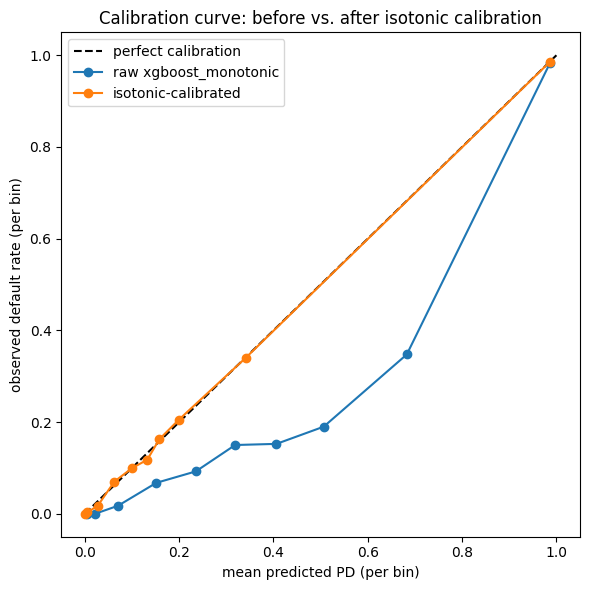

In [23]:
plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], "k--", label="perfect calibration")
plt.plot(mean_pred_raw, frac_pos_raw, "o-", label="raw xgboost_monotonic")
plt.plot(mean_pred_cal, frac_pos_cal, "o-", label="isotonic-calibrated")
plt.xlabel("mean predicted PD (per bin)")
plt.ylabel("observed default rate (per bin)")
plt.title("Calibration curve: before vs. after isotonic calibration")
plt.legend()
plt.tight_layout()
plt.show()

pd_model = calibrated_xgb


## 10. Portfolio loss estimation: expected loss (EL) and CECL

Expected loss, the standard credit-risk framework:
$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$

CECL, basic equation:
$$\text{ACL} = \text{Amortized Cost Basis} \times \text{Estimated Lifetime Loss Rate}$$

Each term maps to a field in the data, or to an assumption where the data has nothing:

| Term | Source | Assumption |
|---|---|---|
| PD | `xgboost_monotonic` predicted probability of default | `loan_paid_back` is a terminal outcome (did the loan ultimately default), not a rolling 12-month one. The predicted probability is therefore treated as a lifetime PD, which is what CECL needs and also works directly in the EL formula. |
| LGD | Not in the dataset (no collateral or recovery field) | Assigned by `loan_purpose` as a proxy for secured versus unsecured, using illustrative benchmark severities: Home = 25%, Car = 40%, all other purposes (debt consolidation, business, medical, education, vacation, other) = 65%. This is an assumption, not derived from data. A real deployment would use actual collateral and recovery history. |
| EAD | `current_balance` | For amortizing installment loans with no revolving redraw, the current outstanding balance is a simple, standard proxy for exposure at default. |
| Amortized cost basis (CECL) | `current_balance` | Same field as EAD, for the basic-equation version of CECL (ignoring unamortized fees, premiums and discounts). |
| Estimated lifetime loss rate (CECL) | PD x LGD | Standard decomposition of a lifetime loss rate. |

Because EAD and amortized cost basis are both `current_balance`, and PD is already a lifetime PD, the CECL formula reduces to the same computation as EL for this dataset. That is expected, not a mistake. CECL replaced the old "incurred loss" model with a lifetime expected-loss reserve, so it lands on the same number as lifetime EL when both use the same PD, LGD and exposure.

In [24]:
df_scored = df.copy()
df_scored["PD"] = pd_model.predict_proba(df_scored[num_cols + cat_cols])[:, 1]

lgd_by_purpose = {"Home": 0.25, "Car": 0.40}
DEFAULT_LGD = 0.65
df_scored["LGD"] = df_scored["loan_purpose"].map(lgd_by_purpose).fillna(DEFAULT_LGD)

df_scored["EAD"] = df_scored["current_balance"]
df_scored["amortized_cost_basis"] = df_scored["current_balance"]

df_scored["EL"] = df_scored["PD"] * df_scored["LGD"] * df_scored["EAD"]

df_scored["lifetime_loss_rate"] = df_scored["PD"] * df_scored["LGD"]
df_scored["ACL"] = df_scored["amortized_cost_basis"] * df_scored["lifetime_loss_rate"]

portfolio_balance = df_scored["current_balance"].sum()
portfolio_EL = df_scored["EL"].sum()
portfolio_ACL = df_scored["ACL"].sum()

print(f"Total portfolio outstanding balance : ${portfolio_balance:,.2f}")
print(f"Portfolio Expected Loss (EL)         : ${portfolio_EL:,.2f}")
print(f"Portfolio CECL Allowance (ACL)        : ${portfolio_ACL:,.2f}")
print(f"EL == ACL under these assumptions?    : {np.isclose(portfolio_EL, portfolio_ACL)}")
print(f"Implied reserve ratio (ACL / balance) : {portfolio_ACL / portfolio_balance:.2%}")


Total portfolio outstanding balance : $486,667,892.63
Portfolio Expected Loss (EL)         : $57,557,149.10
Portfolio CECL Allowance (ACL)        : $57,557,149.10
EL == ACL under these assumptions?    : True
Implied reserve ratio (ACL / balance) : 11.83%


In [25]:
test_idx = X_test.index
test_scored = df_scored.loc[test_idx]
test_balance = test_scored["current_balance"].sum()
test_EL = test_scored["EL"].sum()
print("--- Test-set-only (out-of-sample) portfolio loss ---")
print(f"Test portfolio balance : ${test_balance:,.2f}")
print(f"Test portfolio EL/ACL  : ${test_EL:,.2f}")
print(f"Test reserve ratio     : {test_EL / test_balance:.2%}")

print("\n--- EL / ACL breakdown by loan_purpose (full portfolio) ---")
by_purpose = df_scored.groupby("loan_purpose").agg(
    balance=("current_balance", "sum"),
    avg_PD=("PD", "mean"),
    LGD=("LGD", "first"),
    EL=("EL", "sum"),
).sort_values("EL", ascending=False)
by_purpose["reserve_ratio"] = by_purpose["EL"] / by_purpose["balance"]
by_purpose


--- Test-set-only (out-of-sample) portfolio loss ---
Test portfolio balance : $98,254,528.69
Test portfolio EL/ACL  : $11,507,727.64
Test reserve ratio     : 11.71%

--- EL / ACL breakdown by loan_purpose (full portfolio) ---


,balance,avg_PD,LGD,EL,reserve_ratio
loan_purpose,,,,,
Debt consolidation,1.938687e+08,0.201432,0.65,2.524015e+07,0.130192
Other,6.153424e+07,0.199329,0.65,8.176597e+06,0.132879
Education,4.031305e+07,0.215330,0.65,5.877585e+06,0.145799
Business,3.982050e+07,0.194003,0.65,5.034506e+06,0.126430
Car,5.849290e+07,0.201249,0.40,4.881721e+06,0.083458
Medical,2.823024e+07,0.215479,0.65,4.015735e+06,0.142249
Home,4.926218e+07,0.182754,0.25,2.322723e+06,0.047150
Vacation,1.514612e+07,0.217108,0.65,2.008129e+06,0.132584


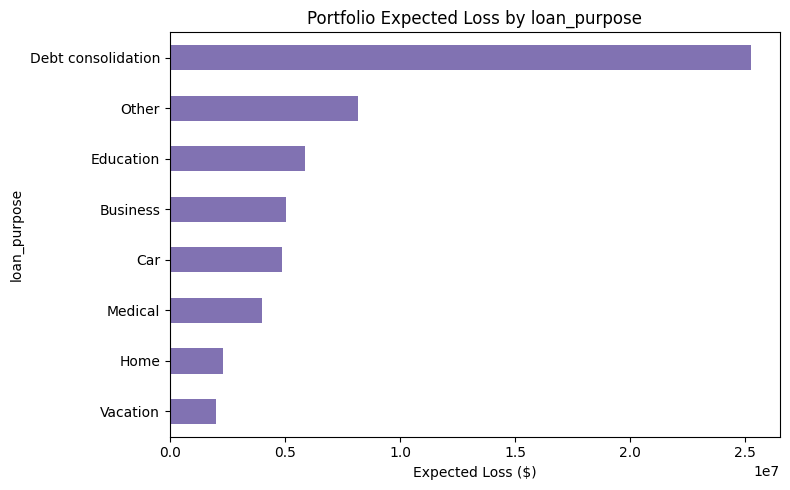

In [26]:
plt.figure(figsize=(8, 5))
by_purpose["EL"].sort_values().plot(kind="barh", color="#8172B2")
plt.xlabel("Expected Loss ($)")
plt.title("Portfolio Expected Loss by loan_purpose")
plt.tight_layout()
plt.show()


## 11. Pricing optimizer: interest rate for a target RAROC

Given an applicant's PD, the optimizer recommends the `interest_rate` that makes the loan hit a target risk-adjusted return on capital (RAROC), instead of pricing from `grade_subgrade` alone.

RAROC as defined here:
$$\text{RAROC} = \frac{\text{Interest Income} - \text{Cost of Funds} - \text{Opex} - \text{Expected Loss}}{\text{Economic Capital}}$$

Per-loan terms, where the rate `r` is the unknown:

| Term | Formula | Notes |
|---|---|---|
| Interest income | `r * EAD` | |
| Cost of funds | `cof_rate * EAD` | Assumed funding cost, default 3.0% |
| Opex | `opex_rate * EAD` | Assumed origination and servicing cost, default 1.5% |
| Expected loss | `PD * LGD * EAD` | PD from `xgboost_monotonic`. LGD by `loan_purpose`, same assumption as the EL/CECL section (Home 25%, Car 40%, else 65%). |
| Economic capital (EC) | `k * LGD * EAD * sqrt(PD * (1 - PD))` | Unexpected loss for a single Bernoulli default event (the standard deviation of loss), scaled by a capital multiplier `k`. Default `k=1`. A `k` near 3 is a common proxy for a 99.9% confidence add-on. |

EAD here is `loan_amount` (the requested principal), not `current_balance`. Pricing happens at origination, before any balance has amortized. The EL/CECL section priced the existing book, so it used `current_balance`.

Interest income is the only term that depends on `r`, and every other term is linear in `EAD`. Solving `RAROC(r) = target` therefore has a closed form, and no numerical solver is needed:

$$r^* = \text{cof\_rate} + \text{opex\_rate} + \text{PD}\times\text{LGD} + \text{target\_RAROC} \times k \times \text{LGD} \times \sqrt{\text{PD}(1-\text{PD})}$$

Read left to right, that is cost of funds, operating cost, the expected-loss rate, and a capital charge that grows with the target return and the loan's own risk. Higher PD, higher LGD or a higher target RAROC all push the recommended rate up.

In [27]:
COF_RATE = 0.03
OPEX_RATE = 0.015
CAPITAL_MULTIPLIER = 1.0
MAX_RATE = 0.60

def recommended_rate(pd_, lgd, target_raroc, cof_rate=COF_RATE, opex_rate=OPEX_RATE,
                      k=CAPITAL_MULTIPLIER):
    """Closed-form interest rate (as a decimal) to hit target_raroc for given PD/LGD."""
    expected_loss_rate = pd_ * lgd
    capital_charge_rate = target_raroc * k * lgd * np.sqrt(pd_ * (1 - pd_))
    r = cof_rate + opex_rate + expected_loss_rate + capital_charge_rate
    return np.clip(r, 0.0, MAX_RATE)

def achieved_raroc(r, pd_, lgd, ead, cof_rate=COF_RATE, opex_rate=OPEX_RATE, k=CAPITAL_MULTIPLIER):
    """Back out RAROC actually achieved at rate r, for verification."""
    net_income = (r - cof_rate - opex_rate) * ead - pd_ * lgd * ead
    ec = k * lgd * ead * np.sqrt(pd_ * (1 - pd_))
    return np.where(ec > 0, net_income / ec, np.nan)


In [28]:
TARGET_RAROC = 0.15

pricing = df.copy()
pricing["PD"] = pd_model.predict_proba(pricing[num_cols + cat_cols])[:, 1]
pricing["LGD"] = pricing["loan_purpose"].map(lgd_by_purpose).fillna(DEFAULT_LGD)
pricing["EAD"] = pricing["loan_amount"]

pricing["recommended_interest_rate_pct"] = 100 * recommended_rate(
    pricing["PD"], pricing["LGD"], TARGET_RAROC
)
pricing["current_interest_rate_pct"] = pricing["interest_rate"]
pricing["rate_delta_pct"] = pricing["recommended_interest_rate_pct"] - pricing["current_interest_rate_pct"]

check = achieved_raroc(
    pricing["recommended_interest_rate_pct"] / 100, pricing["PD"], pricing["LGD"], pricing["EAD"]
)
# PD of exactly 0 or 1 makes economic capital 0, so RAROC is undefined there
interior = (pricing["PD"] > 0) & (pricing["PD"] < 1)
unclipped = (pricing["recommended_interest_rate_pct"] / 100 < MAX_RATE) & interior
print("Target RAROC:", TARGET_RAROC)
print("Achieved RAROC matches target (for unclipped, interior-PD rates)?",
      np.allclose(check[unclipped], TARGET_RAROC, atol=1e-9))
n_boundary = (~interior).sum()
print(f"({n_boundary} rows have PD exactly 0 or 1 from isotonic calibration - priced at the "
      f"cof+opex floor rate, RAROC undefined/trivially exceeded for them)")

pricing[["age", "loan_purpose", "grade_subgrade", "PD", "LGD",
         "current_interest_rate_pct", "recommended_interest_rate_pct", "rate_delta_pct"]].head(10)


Target RAROC: 0.15
Achieved RAROC matches target (for unclipped, interior-PD rates)? True
(4146 rows have PD exactly 0 or 1 from isotonic calibration - priced at the cof+opex floor rate, RAROC undefined/trivially exceeded for them)


,age,loan_purpose,grade_subgrade,PD,LGD,current_interest_rate_pct,recommended_interest_rate_pct,rate_delta_pct
0,59,Car,B5,0.007412,0.40,13.39,5.311136,-8.078864
1,72,Debt consolidation,F1,0.288952,0.65,17.81,27.701349,9.891349
2,49,Business,B4,0.022050,0.65,9.53,7.365043,-2.164957
3,35,Other,A5,0.042050,0.65,7.99,9.190093,1.200093
4,63,Car,D5,0.150061,0.40,15.20,12.645220,-2.554780
5,28,Debt consolidation,B1,0.000000,0.65,12.73,4.500000,-8.230000
6,41,Car,B3,0.845772,0.40,12.48,40.497888,28.017888
7,59,Debt consolidation,A3,0.000000,0.65,8.45,4.500000,-3.950000
8,39,Home,C4,0.000000,0.25,9.95,4.500000,-5.450000
9,43,Car,B1,0.214386,0.40,11.81,15.537823,3.727823


In [29]:
print("--- Recommended vs. current interest rate, overall ---")
print(pricing[["current_interest_rate_pct", "recommended_interest_rate_pct", "rate_delta_pct"]].describe())

print("\n--- Mean rate delta by grade_subgrade (recommended - current) ---")
print(pricing.groupby("grade_subgrade")["rate_delta_pct"].mean().sort_values())

n_underpriced = (pricing["rate_delta_pct"] > 0).sum()
n_overpriced = (pricing["rate_delta_pct"] < 0).sum()
print(f"\nLoans currently priced BELOW target-RAROC rate (underpriced): {n_underpriced} "
      f"({n_underpriced/len(pricing):.1%})")
print(f"Loans currently priced ABOVE target-RAROC rate (overpriced):  {n_overpriced} "
      f"({n_overpriced/len(pricing):.1%})")


--- Recommended vs. current interest rate, overall ---
       current_interest_rate_pct  recommended_interest_rate_pct  \
count               20000.000000                   20000.000000   
mean                   12.400626                      17.543003   
std                     2.442729                      15.191379   
min                     3.140000                       4.500000   
25%                    10.740000                       6.975045   
50%                    12.400000                      13.254224   
75%                    14.002500                      19.987699   
max                    22.510000                      60.000000   

       rate_delta_pct  
count    20000.000000  
mean         5.142377  
std         14.887712  
min        -14.590000  
25%         -4.305137  
50%          0.823729  
75%          7.357634  
max         55.320000  

--- Mean rate delta by grade_subgrade (recommended - current) ---
grade_subgrade
A1    -2.081505
A2    -1.528272
A3    -1.20

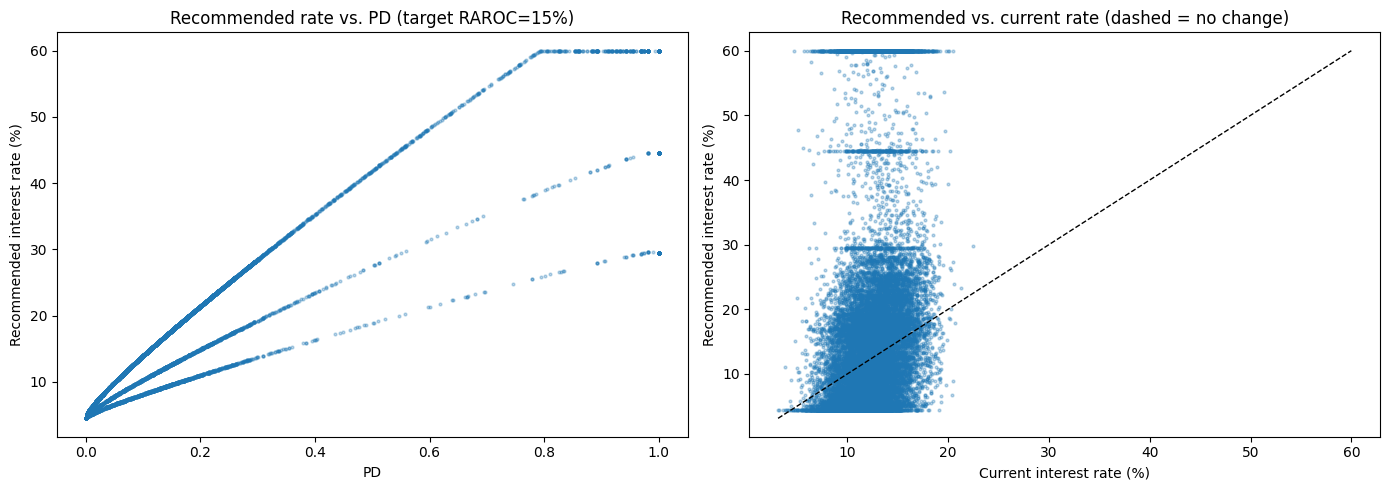

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(pricing["PD"], pricing["recommended_interest_rate_pct"], s=4, alpha=0.3)
axes[0].set_xlabel("PD")
axes[0].set_ylabel("Recommended interest rate (%)")
axes[0].set_title(f"Recommended rate vs. PD (target RAROC={TARGET_RAROC:.0%})")

axes[1].scatter(pricing["current_interest_rate_pct"], pricing["recommended_interest_rate_pct"],
                s=4, alpha=0.3)
lims = [pricing[["current_interest_rate_pct", "recommended_interest_rate_pct"]].min().min(),
        pricing[["current_interest_rate_pct", "recommended_interest_rate_pct"]].max().max()]
axes[1].plot(lims, lims, "k--", linewidth=1)
axes[1].set_xlabel("Current interest rate (%)")
axes[1].set_ylabel("Recommended interest rate (%)")
axes[1].set_title("Recommended vs. current rate (dashed = no change)")

plt.tight_layout()
plt.show()


In [31]:
example = X_test.iloc[[0]]
pd_example = pd_model.predict_proba(example)[0, 1]
lgd_example = example["loan_purpose"].map(lgd_by_purpose).fillna(DEFAULT_LGD).iloc[0]
ead_example = df.loc[example.index, "loan_amount"].iloc[0]

for target in [0.10, 0.15, 0.20]:
    r = recommended_rate(pd_example, lgd_example, target)
    print(f"target RAROC={target:.0%} -> recommended rate={r:.2%} "
          f"(PD={pd_example:.2%}, LGD={lgd_example:.0%}, loan_amount=${ead_example:,.0f})")


target RAROC=10% -> recommended rate=4.91% (PD=0.20%, LGD=65%, loan_amount=$13,722)
target RAROC=15% -> recommended rate=5.06% (PD=0.20%, LGD=65%, loan_amount=$13,722)
target RAROC=20% -> recommended rate=5.20% (PD=0.20%, LGD=65%, loan_amount=$13,722)


Caveats on the pricing optimizer:

- The recommended rates are sensitive to four assumed inputs, none fitted from data: `cof_rate` (3.0%), `opex_rate` (1.5%), the capital multiplier `k` (1.0) and `target_raroc` (15%). With the calibrated PD (Section 9), the gap to current rates is much smaller than with the raw, overconfident PD. The mean recommended rate is 17.5% against a current 12.4%, and the medians nearly match (13.3% against 12.4%). The split between underpriced and overpriced loans is close to even (53.5% / 46.5%). With the raw model, 71% of loans looked underpriced.
- About 4,146 of 20,000 loans (21%) get a PD of exactly 0.0 from the isotonic calibration and are priced at the cost-of-funds plus opex floor (4.5%) with no risk premium. Isotonic regression fits a step function, so it can flatten a whole low-risk region to exactly 0. If smoother probabilities in the low-risk tail matter more than calibration accuracy, `method="sigmoid"` (Platt scaling) in Section 9 is less flexible but smoother.
- Rates are clipped to the 60% bound from `cleaning_system/config.yaml`. Very high-PD applicants still hit the cap, which means no rate can deliver the target RAROC for them under these assumptions. In practice that is a signal to decline, not reprice.
- PD, LGD and EAD are treated as fixed inputs, but raising the rate on a marginal borrower can raise their true PD (adverse selection). That feedback loop is not modeled.
- Rerun the pricing cells with different `COF_RATE`, `OPEX_RATE`, `CAPITAL_MULTIPLIER` and `TARGET_RAROC` values to see the recommended rates under other return targets.

## 12. Fair lending: bias and disparate-impact audit

Legal framework (U.S.). Credit decisions fall mainly under the Equal Credit Opportunity Act (ECOA, 15 U.S.C. Section 1691 et seq.) and its Regulation B (12 C.F.R. Part 1002). They prohibit discrimination in any aspect of a credit transaction based on race, color, religion, national origin, sex, marital status, age (if the applicant can enter a contract), receipt of public assistance income, or good-faith exercise of rights under the Consumer Credit Protection Act. When a loan is secured by a dwelling, the Fair Housing Act (FHA, 42 U.S.C. Section 3601 et seq.) adds similar protections. Both recognize disparate-impact liability (neutral practices with discriminatory effects) as well as disparate treatment. The Supreme Court affirmed disparate impact under the FHA in *Texas Dept. of Housing & Community Affairs v. Inclusive Communities Project*, 576 U.S. 519 (2015). Regulation B Section 1002.6(b)(2)-(3) also sets a rule for age in empirically derived scoring systems, the "elderly rule". Age can be a predictive variable, but applicants 62 and older cannot be given a negative factor because of age compared with a similarly situated younger applicant.

Data limitation. The dataset has no race, ethnicity, religion or national origin fields, the ones most often examined in ECOA and FHA exams. The audit is therefore partial. It covers the demographic fields present (`gender`, `age`, and `education_level` as an exploratory proxy check) and is not a complete ECOA/FHA review. A real deployment would get race and ethnicity from HMDA-reported application data or estimate it with Bayesian Improved Surname Geocoding (BISG), and would involve outside fair-lending counsel.

- `gender` and `age` (62+ versus under 62, the Reg B elderly-rule threshold) are ECOA-protected classes.
- `education_level` is not an ECOA/FHA-protected class. It is included as a proxy-discrimination screen, since a neutral variable can still cause disparate impact if it correlates with a protected class, for instance through socioeconomic or geographic patterns.

Metrics, from the Fairlearn library (fairlearn.org):

- Adverse Impact Ratio (AIR) is the approval rate of a group divided by the approval rate of a reference group. It is the lending version of the EEOC four-fifths rule (29 C.F.R. Section 1607.4(D), originally an employment-selection standard). U.S. bank regulators (CFPB, OCC, FDIC, Federal Reserve; see the Interagency Fair Lending Examination Procedures) use it as a screening threshold. An AIR below 0.80 flags a group for closer review. It is not a finding of illegal discrimination.
- Equal Opportunity Difference (Hardt, Price & Srebro, *Equality of Opportunity in Supervised Learning*, NeurIPS 2016) is the gap in true positive rate between groups, where the true positive rate is P(model approves | applicant would have repaid). It asks whether creditworthy applicants in every group are approved at the same rate. Values near 0 mean parity.

Both metrics are computed on the held-out test set from the model's decisions at a 0.5 probability threshold (approve = predicted probability of default below 0.5), consistent with the classification metrics earlier in the notebook.

In [32]:
from fairlearn.metrics import (
    MetricFrame, selection_rate, true_positive_rate, false_positive_rate,
    demographic_parity_ratio, demographic_parity_difference,
    equalized_odds_ratio, equalized_odds_difference,
)

fair_model = models["xgboost_monotonic_calibrated"]
proba_default_test = fair_model.predict_proba(X_test)[:, 1]

approved = (proba_default_test < 0.5).astype(int)
actually_repaid = (y_test == 0).astype(int)

sensitive = pd.DataFrame({
    "gender": X_test["gender"].values,
    "age_group": np.where(X_test["age"].values >= 62, "62+ (elderly, ECOA-protected)", "under 62"),
    "education_level": X_test["education_level"].values,
}, index=X_test.index)

print(sensitive["gender"].value_counts())
print()
print(sensitive["age_group"].value_counts())
print()
print(sensitive["education_level"].value_counts())


gender
Female    2022
Male      1893
Other       85
Name: count, dtype: int64

age_group
under 62                         2978
62+ (elderly, ECOA-protected)    1022
Name: count, dtype: int64

education_level
Bachelor's     1617
High School    1157
Master's        768
Other           291
PhD             167
Name: count, dtype: int64


In [33]:
REFERENCE_GROUPS = {
    "gender": "Male",
    "age_group": "under 62",
    "education_level": None,
}

def air_table(attr):
    mf = MetricFrame(
        metrics={"selection_rate": selection_rate, "tpr": true_positive_rate, "fpr": false_positive_rate},
        y_true=actually_repaid, y_pred=approved, sensitive_features=sensitive[attr],
    )
    by_group = mf.by_group.copy()
    ref = REFERENCE_GROUPS[attr] or by_group["selection_rate"].idxmax()
    by_group["AIR_vs_ref"] = by_group["selection_rate"] / by_group.loc[ref, "selection_rate"]
    by_group["equal_opportunity_diff_vs_ref"] = by_group["tpr"] - by_group.loc[ref, "tpr"]
    by_group["n"] = sensitive[attr].value_counts()
    by_group.attrs["reference_group"] = ref
    return by_group

air_gender = air_table("gender")
air_age = air_table("age_group")
air_edu = air_table("education_level")

for name, tbl in [("gender", air_gender), ("age_group", air_age), ("education_level", air_edu)]:
    print(f"=== {name} (reference group: {tbl.attrs['reference_group']}) ===")
    print(tbl.round(4))
    print()


=== gender (reference group: Male) ===
        selection_rate     tpr     fpr  AIR_vs_ref  \
gender                                               
Female          0.8818  0.9932  0.4213      0.9924   
Male            0.8885  0.9920  0.4897      1.0000   
Other           0.8706  0.9855  0.3750      0.9798   

        equal_opportunity_diff_vs_ref     n  
gender                                       
Female                         0.0012  2022  
Male                           0.0000  1893  
Other                         -0.0065    85  

=== age_group (reference group: under 62) ===
                               selection_rate     tpr     fpr  AIR_vs_ref  \
age_group                                                                   
62+ (elderly, ECOA-protected)          0.8973  0.9976  0.4745      1.0191   
under 62                               0.8805  0.9907  0.4470      1.0000   

                               equal_opportunity_diff_vs_ref     n  
age_group                          

In [34]:
print("--- Fairlearn overall summary metrics (test set, xgboost_monotonic @ 0.5 threshold) ---")
for attr in ["gender", "age_group", "education_level"]:
    dp_ratio = demographic_parity_ratio(actually_repaid, approved, sensitive_features=sensitive[attr])
    dp_diff = demographic_parity_difference(actually_repaid, approved, sensitive_features=sensitive[attr])
    eo_ratio = equalized_odds_ratio(actually_repaid, approved, sensitive_features=sensitive[attr])
    eo_diff = equalized_odds_difference(actually_repaid, approved, sensitive_features=sensitive[attr])
    print(f"{attr:<16} demographic_parity_ratio={dp_ratio:.4f}  demographic_parity_diff={dp_diff:.4f}  "
          f"equalized_odds_ratio={eo_ratio:.4f}  equalized_odds_diff={eo_diff:.4f}")

print("""
Note: fairlearn's demographic_parity_ratio/equalized_odds_ratio compare the WORST-CASE pair
of groups (min/max across all groups), not necessarily protected-vs-reference — use the
per-group AIR tables above for the regulator-style reference-group comparison, and these
overall figures as a quick worst-case screen.
""")


--- Fairlearn overall summary metrics (test set, xgboost_monotonic @ 0.5 threshold) ---
gender           demographic_parity_ratio=0.9798  demographic_parity_diff=0.0179  equalized_odds_ratio=0.7657  equalized_odds_diff=0.1147


age_group        demographic_parity_ratio=0.9813  demographic_parity_diff=0.0168  equalized_odds_ratio=0.9421  equalized_odds_diff=0.0275
education_level  demographic_parity_ratio=0.9594  demographic_parity_diff=0.0370  equalized_odds_ratio=0.8452  equalized_odds_diff=0.0795

Note: fairlearn's demographic_parity_ratio/equalized_odds_ratio compare the WORST-CASE pair
of groups (min/max across all groups), not necessarily protected-vs-reference — use the
per-group AIR tables above for the regulator-style reference-group comparison, and these
overall figures as a quick worst-case screen.



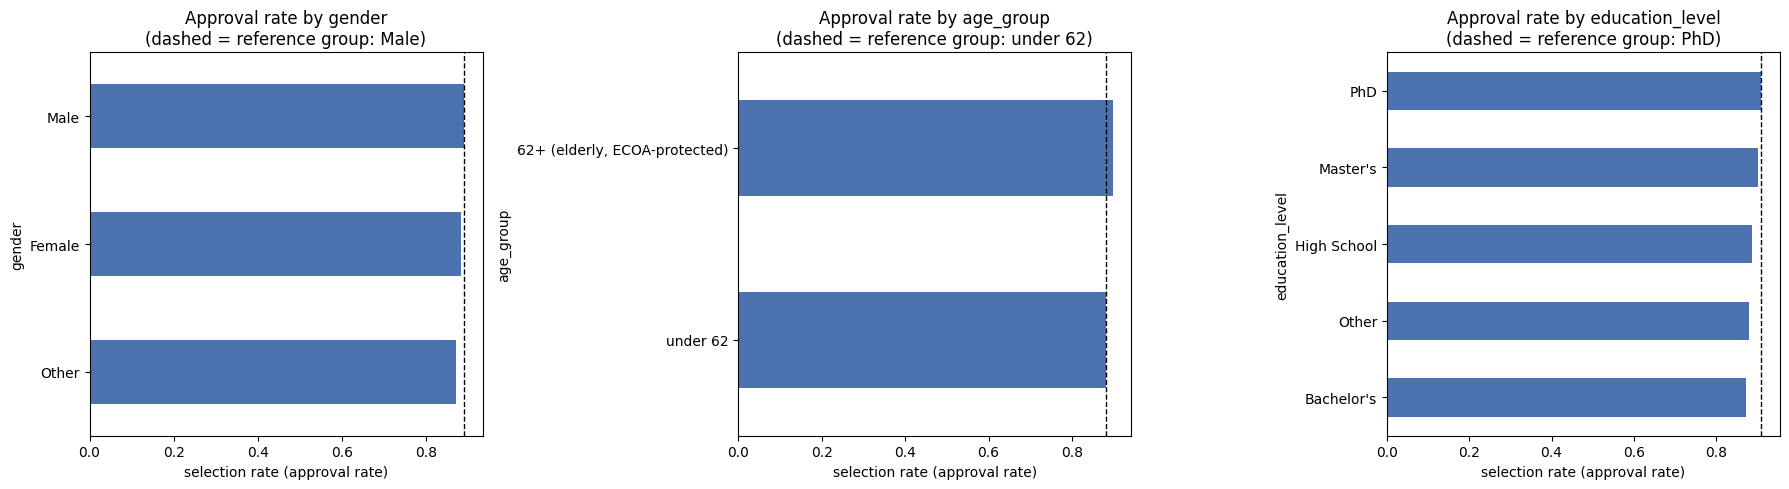

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, tbl) in zip(axes, [("gender", air_gender), ("age_group", air_age), ("education_level", air_edu)]):
    tbl["selection_rate"].sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
    ax.axvline(tbl.loc[tbl.attrs["reference_group"], "selection_rate"], color="black", linestyle="--", linewidth=1)
    ax.set_title(f"Approval rate by {name}\n(dashed = reference group: {tbl.attrs['reference_group']})")
    ax.set_xlabel("selection rate (approval rate)")
plt.tight_layout()
plt.show()


Results (test set, n=4,000; `xgboost_monotonic_calibrated` at a 0.5 threshold):

| Attribute | Group (n) | AIR vs. reference | Equal Opportunity Diff. vs. reference |
|---|---|---|---|
| gender (ref: Male, n=1,893) | Female (n=2,022) | 0.992 | +0.001 |
| gender (ref: Male, n=1,893) | Other (n=85) | 0.980 | -0.007 |
| age_group (ref: under 62, n=2,978) | 62+ / elderly (n=1,022) | 1.019 | +0.007 |
| education_level (ref: PhD, n=167) | Bachelor's (n=1,617) | 0.959 | -0.002 |
| education_level (ref: PhD, n=167) | High School (n=1,157) | 0.974 | -0.000 |
| education_level (ref: PhD, n=167) | Master's (n=768) | 0.991 | +0.002 |
| education_level (ref: PhD, n=167) | Other (n=291) | 0.967 | +0.003 |

Findings, with the calibrated model (Section 9):

- Age (ECOA elderly rule, 62+): clean. AIR is 1.019 and the Equal Opportunity Difference is +0.007. There is no meaningful disparity, and if anything elderly applicants do slightly better.
- Gender (Male vs. Female): clean. AIR is 0.992 and the Equal Opportunity Difference is +0.001.
- Gender ("Other", n=85): clean too. With the raw, uncalibrated model this group showed a borderline AIR of 0.820 and an Equal Opportunity Difference of -0.152, both worrying on their face. After the PD calibration fix (Section 9) it shows AIR 0.980 and -0.007. An apparent fair-lending flag on a small group can come from a poorly calibrated model and not from a real disparity, and chasing it would have sent audit effort to the wrong cause.
- Education level (not protected, exploratory): no flags, same as before calibration. AIRs run 0.96 to 1.00 and Equal Opportunity Differences are essentially zero (-0.002 to +0.003).

Reading the results:

- An `AIR_vs_ref` below 0.80 flags a group under the four-fifths screening convention. It calls for a closer look, meaning a root-cause analysis of which features drive the gap and whether a less discriminatory alternative model reaches similar accuracy with a smaller gap. It is not an automatic finding of unlawful discrimination.
- An `equal_opportunity_diff_vs_ref` far from 0 means creditworthy applicants (`actually_repaid=1`) in that group are approved at a different rate than creditworthy applicants in the reference group. That is a narrower question than AIR's "are all groups equally likely to be approved at all?". It asks whether the model is equally good at saying yes to good borrowers across groups.
- If either metric flags a group, the next step is to check whether `grade_subgrade` or `employment_status`, the model's dominant features (see Feature importance), correlate with that group. That would make them a proxy channel even though neither is a protected class.

Next steps for a production deployment:

1. Get race, ethnicity and national origin (directly or through BISG) to run the complete ECOA/FHA comparison set, not just the fields in this dataset.
2. If any AIR or Equal Opportunity Difference flag appears, search for a less discriminatory alternative, for example with Fairlearn's `ExponentiatedGradient` or `ThresholdOptimizer`, to see whether a comparably accurate model has a smaller gap. This follows CFPB guidance on model risk management for ML underwriting models.
3. Rerun the audit regularly, say quarterly, as the applicant population and the model drift. A one-time audit is a snapshot, not a standing guarantee.

## 13. Pre-underwriting model (dropping `grade_subgrade`)

`grade_subgrade` is very likely a risk grade the lender assigns at underwriting, after already assessing the applicant. That makes it close to a proxy for the answer, not an independent input. It is fine for explaining defaults on loans that were already approved, which is what the sections above do. It makes the main model unusable for screening an applicant before a grade exists, which is when a lender most needs a PD estimate.

This section retrains the same recipe (monotonic-constrained XGBoost, isotonic calibration) on the raw applicant and loan fields only, with `grade_subgrade` removed. Hyperparameters, constraint logic and calibration method are identical to the main model, so the comparison isolates the effect of dropping that one field.

In [36]:
cat_cols_preuw = [c for c in cat_cols if c != "grade_subgrade"]
X_preuw = df[num_cols + cat_cols_preuw]
X_train_preuw, X_test_preuw, y_train_preuw, y_test_preuw = train_test_split(
    X_preuw, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

preprocess_preuw = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols_preuw),
])
preprocess_preuw.fit(X_train_preuw)
n_cat_preuw = len(preprocess_preuw.named_transformers_["cat"].get_feature_names_out())
monotone_constraints_preuw = tuple(monotonic_direction[c] for c in num_cols) + (0,) * n_cat_preuw

xgb_preuw = Pipeline([
    ("prep", preprocess_preuw),
    ("clf", XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=(y_train_preuw == 0).sum() / (y_train_preuw == 1).sum(),
        monotone_constraints=monotone_constraints_preuw,
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1,
    )),
])
xgb_preuw.fit(X_train_preuw, y_train_preuw)

pd_model_preuw = CalibratedClassifierCV(clone(xgb_preuw), method="isotonic", cv=5)
pd_model_preuw.fit(X_train_preuw, y_train_preuw)

proba_preuw = pd_model_preuw.predict_proba(X_test_preuw)[:, 1]
pred_preuw = (proba_preuw >= 0.5).astype(int)
auc_preuw = roc_auc_score(y_test_preuw, proba_preuw)
ap_preuw = average_precision_score(y_test_preuw, proba_preuw)
brier_preuw = brier_score_loss(y_test_preuw, proba_preuw)

print("=== Pre-underwriting model (no grade_subgrade), calibrated ===")
print(f"ROC-AUC: {auc_preuw:.4f}  |  PR-AUC: {ap_preuw:.4f}  |  Brier: {brier_preuw:.4f}")
print(classification_report(y_test_preuw, pred_preuw))
print(f"\nFor comparison, the main model (WITH grade_subgrade, calibrated): "
      f"ROC-AUC={roc_auc_score(y_test, cal_proba_test):.4f}, "
      f"Brier={brier_score_loss(y_test, cal_proba_test):.4f}")


=== Pre-underwriting model (no grade_subgrade), calibrated ===
ROC-AUC: 0.8939  |  PR-AUC: 0.7890  |  Brier: 0.0787
              precision    recall  f1-score   support

           0       0.90      0.99      0.94      3200
           1       0.96      0.54      0.69       800

    accuracy                           0.90      4000
   macro avg       0.93      0.77      0.82      4000
weighted avg       0.91      0.90      0.89      4000


For comparison, the main model (WITH grade_subgrade, calibrated): ROC-AUC=0.8933, Brier=0.0786


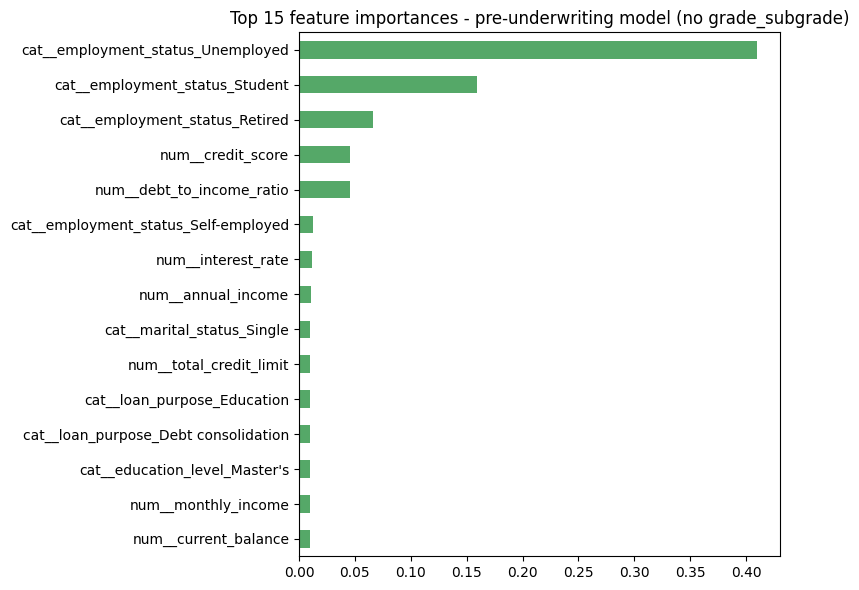

cat__employment_status_Unemployed       0.409896
cat__employment_status_Student          0.159382
cat__employment_status_Retired          0.066098
num__credit_score                       0.045667
num__debt_to_income_ratio               0.045420
cat__employment_status_Self-employed    0.012371
num__interest_rate                      0.012014
num__annual_income                      0.010342
cat__marital_status_Single              0.010306
num__total_credit_limit                 0.010108
dtype: float32

In [37]:
feat_names_preuw = preprocess_preuw.get_feature_names_out()
importances_preuw = xgb_preuw.named_steps["clf"].feature_importances_
fi_preuw = pd.Series(importances_preuw, index=feat_names_preuw).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
fi_preuw.head(15).sort_values().plot(kind="barh", color="#55A868")
plt.title("Top 15 feature importances - pre-underwriting model (no grade_subgrade)")
plt.tight_layout()
plt.show()

fi_preuw.head(10)


Result: dropping `grade_subgrade` barely moves ranking power. ROC-AUC is 0.8939 against 0.8933 for the main model, which is statistically indistinguishable given the +/-0.46-point cross-validation spread from Section 7, and the Brier score matches to four decimals (0.0787 against 0.0786). That contradicts the earlier assumption that removing the lender's own grade would clearly cost accuracy. The likely explanation is that `grade_subgrade` is a near-deterministic function of the same raw fields (`debt_to_income_ratio`, `credit_score`, `employment_status` and so on; see the feature importances above), so once those are in the model the grade adds little.

What does change is the precision/recall balance at the 0.5 threshold. Recall on defaults falls from about 0.70 to 0.54, and precision rises to 0.96. Without the grade, the model is more conservative about flagging applicants as high-risk, even though it ranks them just as well.

This model (`pd_model_preuw`) is the one for pre-approval and application-time scoring, and there is no accuracy penalty for using it. The calibrated `xgboost_monotonic_calibrated` model from Section 9 stays in use for portfolio loss, pricing and the fair-lending audit, because those concern loans that were already graded and approved. It is not meaningfully more accurate.

## 14. Saving model artifacts

Everything above lives inside this notebook's run, and the fitted models can't be reused elsewhere without rerunning all 14 sections. This section saves the two production models (main and pre-underwriting, both calibrated) with `joblib`, plus a `requirements.txt` of the environment they were fit in. A separate script or service can then load the models and score new applicants without this notebook.

In [38]:
import joblib
import sklearn, xgboost, fairlearn, matplotlib, seaborn, scipy

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

joblib.dump(calibrated_xgb, f"{MODEL_DIR}/xgboost_monotonic_calibrated.joblib")
joblib.dump(pd_model_preuw, f"{MODEL_DIR}/xgboost_monotonic_calibrated_preunderwriting.joblib")

metadata = {
    "main_model": {
        "file": "xgboost_monotonic_calibrated.joblib",
        "features_numeric": num_cols,
        "features_categorical": cat_cols,
        "use_case": "scoring / explaining already-graded or approved loans "
                    "(includes grade_subgrade)",
        "test_roc_auc": float(roc_auc_score(y_test, cal_proba_test)),
        "test_brier": float(brier_score_loss(y_test, cal_proba_test)),
    },
    "pre_underwriting_model": {
        "file": "xgboost_monotonic_calibrated_preunderwriting.joblib",
        "features_numeric": num_cols,
        "features_categorical": cat_cols_preuw,
        "use_case": "pre-approval / application-time scoring (no grade_subgrade)",
        "test_roc_auc": float(auc_preuw),
        "test_brier": float(brier_preuw),
    },
    "random_state": RANDOM_STATE,
    "target": "default (= 1 - loan_paid_back)",
}
with open(f"{MODEL_DIR}/metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

versions = [
    f"pandas=={pd.__version__}",
    f"numpy=={np.__version__}",
    f"scikit-learn=={sklearn.__version__}",
    f"xgboost=={xgboost.__version__}",
    f"fairlearn=={fairlearn.__version__}",
    f"matplotlib=={matplotlib.__version__}",
    f"seaborn=={seaborn.__version__}",
    f"scipy=={scipy.__version__}",
    f"joblib=={joblib.__version__}",
]
with open("requirements.txt", "w") as f:
    f.write("\n".join(versions) + "\n")

print("Saved:")
for f in os.listdir(MODEL_DIR):
    print(" ", f"{MODEL_DIR}/{f}")
print("  requirements.txt")
print()
print("--- requirements.txt ---")
print("\n".join(versions))


Saved:
  models/metadata.json
  models/xgboost_monotonic_calibrated.joblib
  models/xgboost_monotonic_calibrated_preunderwriting.joblib
  requirements.txt

--- requirements.txt ---
pandas==2.3.2
numpy==2.3.2
scikit-learn==1.7.1
xgboost==3.0.5
fairlearn==0.14.0
matplotlib==3.10.6
seaborn==0.13.2
scipy==1.16.1
joblib==1.5.2


In [39]:
loaded_model = joblib.load(f"{MODEL_DIR}/xgboost_monotonic_calibrated.joblib")
sample_applicant = X_test.iloc[[0]]
reloaded_pd = loaded_model.predict_proba(sample_applicant)[0, 1]
original_pd = calibrated_xgb.predict_proba(sample_applicant)[0, 1]
print(f"Reloaded model PD: {reloaded_pd:.6f}  |  original in-memory model PD: {original_pd:.6f}  "
      f"|  match: {np.isclose(reloaded_pd, original_pd)}")


Reloaded model PD: 0.001951  |  original in-memory model PD: 0.001951  |  match: True


## 15. Notes

- `grade_subgrade` and `employment_status` dominate feature importance. These are likely lender-assigned risk fields (the grade tracks default rate almost perfectly: A grades about 4-8%, F grades about 30-35%), so the main model is partly re-deriving an existing risk label instead of scoring from raw applicant data.
- For pre-underwriting scoring, before a grade is assigned, Section 13 drops `grade_subgrade` and retrains. Ranking power did not fall, and the signal comes from raw applicant fields (`debt_to_income_ratio`, `credit_score`, `employment_status`, income, delinquency history).
- The anomaly flags in `cleaning_system/flagged_output.csv` were checked separately. 1,455 of 20,000 rows were flagged, with 0 domain-rule violations and 0 cross-field consistency violations. The flags reflect statistical skew in the income and balance columns, not data errors, so no rows were dropped.